# 벡터 DB와 검색

#### 필요한 패키지 설치
`pip install langchain-chroma`

In [2]:
import chromadb
from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv() 
EMBEDDING_MODEL_NAME = "gemini-embedding-2"


C:\Users\snail\AppData\Local\Temp\ipykernel_25248\1261016437.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


## 벡터 DB란?

이전 시간에 텍스트를 임베딩 벡터로 변환하는 방법을 배웠다. 이제 이 벡터들을 **저장**하고 **검색**해야 한다.

일반적인 데이터베이스(MySQL, PostgreSQL 등)는 정확한 값의 일치(`WHERE name = '홍길동'`)나 범위 검색(`WHERE age > 20`)에 최적화되어 있다. 하지만 벡터 검색은 다르다. "이 벡터와 가장 비슷한 벡터 k개를 찾아줘"라는 **유사도 검색**이 필요하다.

1536차원짜리 벡터 10만 개가 있다고 해보자. 질문이 들어올 때마다 10만 개를 하나하나 비교하면 너무 느리다. 벡터 DB는 이 문제를 효율적으로 해결하기 위해 만들어진 전용 데이터베이스이다.

### 직관적으로 이해하기: 표 vs 지도

RDB가 데이터를 **표(Table)** 형태로 관리한다면, 벡터 DB는 데이터를 **지도(Map)** 처럼 관리한다.

[RDB] - 엑셀 시트처럼 행과 열에 정리

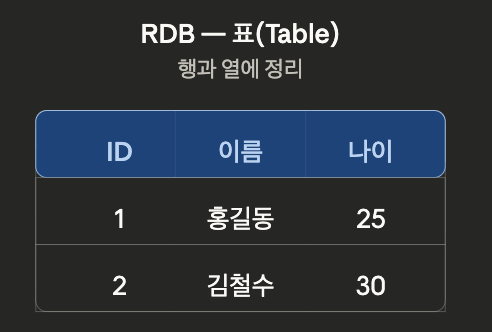

[벡터 DB] - 좌표 공간에 점으로 배치 (의미가 비슷하면 가까이)

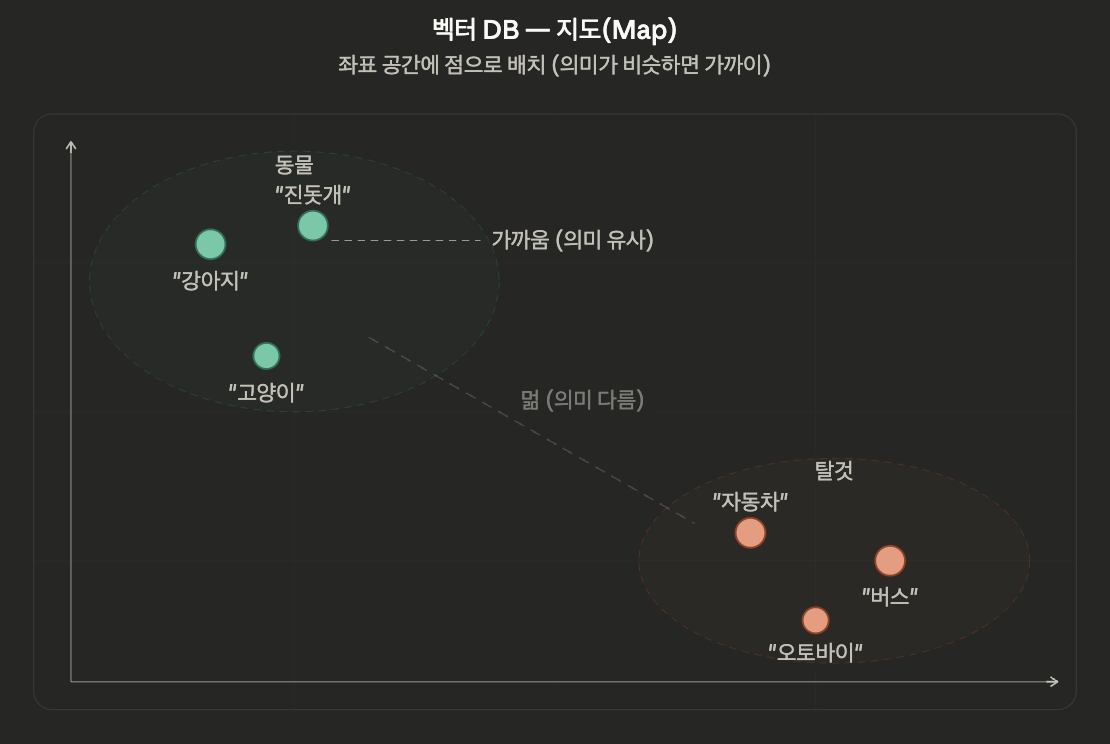

물리적으로는 벡터 DB도 결국 서버의 디스크에 데이터가 쌓인다. 하지만 논리적으로는 각 데이터가 **다차원 좌표 공간에서 위치를 점유**하는 구조이다. 이 좌표에서의 **위치가 곧 의미**이고, **검색은 거리를 재는 것**이다.

### 왜 일반 DB로는 부족한가?

| | 일반 DB | 벡터 DB |
|---|---|---|
| **검색 방식** | 정확한 값 매칭 (=, >, <) | 유사도 기반 근사 검색 |
| **인덱스** | B-Tree, Hash | HNSW, IVF 등 벡터 전용 인덱스 |
| **데이터** | 숫자, 문자열, 날짜 | 고차원 벡터 (수백~수천 차원) |
| **결과** | 조건에 맞는 정확한 결과 | "가장 비슷한" 근사 결과 |

일반 DB에서 벡터 유사도를 계산하려면 모든 행에 대해 코사인 유사도를 계산해야 한다. 이는 O(n)으로, 데이터가 늘어날수록 선형으로 느려진다.

### ANN (Approximate Nearest Neighbor)

벡터 DB의 핵심은 **근사 최근접 이웃(ANN)** 알고리즘이다. Exact Search와 동일한 결과를 항상 보장하지 않는 대신, 대규모 벡터에서 검색 속도를 높인다. 검색 재현율은 데이터와 인덱스 설정에 따라 달라진다.

```
Exact Search (전수 조사):  벡터 10만 개 × 1536차원 → 모두 비교 → 느림
ANN (근사 검색):           인덱스로 후보를 빠르게 좁힘 → 빠름
```

대표적인 ANN 인덱싱 방식:

| 알고리즘 | 원리 | 특징 |
|---------|------|------|
| **HNSW** | 가까운 벡터들을 간선으로 연결한 다층 그래프를 탐색 | 검색 속도와 재현율이 우수하지만 그래프 저장에 추가 메모리가 필요함. 단일 노드 Chroma의 기본 ANN 인덱스 |
| **IVF** | 벡터 공간을 여러 클러스터로 나누고, 질문과 가까운 일부 클러스터만 검색 | 검색할 클러스터 수에 따라 속도와 재현율이 달라짐. PQ 같은 압축 기법과 결합할 수 있으며 FAISS에서 대표적으로 지원 |

> 실무에서 ANN의 내부 동작을 직접 구현할 일은 없다. 중요한 건 "벡터 DB가 어떻게 빠른 검색을 가능하게 하는지"의 원리를 이해하는 것이다.

### 벡터 DB의 동작 흐름

```
[저장]
문서 → 청킹 → 임베딩 모델 → 벡터 + 메타데이터 → 벡터 DB에 저장 (인덱스 구축)

[검색]
질문 → 임베딩 모델 → 질문 벡터 → 벡터 DB에서 ANN 검색 → 상위 k개 문서 반환
```

저장할 때 벡터뿐 아니라 **원본 텍스트**와 **메타데이터**(출처, 페이지 번호 등)도 함께 저장한다. 검색 결과로 벡터가 아닌 원본 텍스트를 돌려받아야 LLM에 전달할 수 있기 때문이다.

### 메타데이터 (Metadata)

벡터 DB에 저장되는 데이터는 크게 세 가지로 구성된다.

| 구성 요소 | 설명 | 예시 |
|----------|------|------|
| **벡터** | 임베딩 모델이 생성한 좌표값. 유사도 검색에 사용 | `[0.12, -0.34, 0.56, ...]` |
| **원본 텍스트** | 벡터의 원래 문서 내용. LLM에 전달할 때 사용 | `"연차는 최소 1일 전에 신청..."` |
| **메타데이터** | 벡터에 붙이는 구조화된 정보. 필터링, 문서 식별, 출처 표시에 사용 | `{"source": "사내규정.pdf", "page": 3}` |

**메타데이터는 임베딩되지 않는다.** 좌표 공간에 점을 찍은 뒤, 그 점에 포스트잇을 붙여놓는 것과 같다. 유사도 검색의 대상이 아니라, 검색 결과를 **필터링**할 때 사용한다.

```
검색 조건:
1. 메타데이터 조건으로 검색 대상을 제한: "user_id가 'kim'인 데이터만 대상"  ← 정확한 매칭 (RDB처럼)
2. 조건을 만족하는 문서 중에서 질문과 가장 가까운 k개를 반환  ← 유사도 기반
```

메타데이터를 쓰는 이유는 벡터 검색만으로는 **"이 데이터가 누구 것인지"**, **"어떤 문서에서 왔는지"** 를 구분할 수 없기 때문이다. 대표적인 사용 사례:

- **멀티테넌트**: 사용자별로 업로드한 문서가 다를 때, `user_id`로 필터링하여 본인 문서만 검색
- **문서 구분**: 여러 PDF를 하나의 컬렉션에 저장하고, `source`로 특정 문서만 검색
- **페이지 범위**: 특정 페이지 범위의 내용만 검색

> LangChain의 Document Loader들은 메타데이터를 **자동으로 생성**한다. 예를 들어 `PyPDFLoader`는 `source`(파일 경로)와 `page`(0부터 시작하는 페이지 인덱스)를 자동으로 넣어준다. 따라서 `page=0`은 PDF의 첫 번째 페이지를 뜻한다. 추가 메타데이터가 필요하면 Document 객체의 `metadata` 딕셔너리에 직접 추가하면 된다.

> 메타데이터에는 **필터링, 문서 식별, 출처 표시에 필요한 구조화된 정보**를 넣는다. 만약 메타데이터의 내용으로도 "의미 검색"을 하고 싶다면, 해당 내용을 원본 텍스트에 포함시켜 함께 임베딩해야 한다.

### 벡터 DB 비교

| 도구 | 분류와 특징 | 적합한 상황 |
|---|---|---|
| **Chroma** | 임베디드·서버·클라우드 방식을 지원하는 벡터 DB. Python에서는 로컬 디스크 저장이 간단함 | 학습, 프로토타입, 소규모 RAG |
| **pgvector** | PostgreSQL 확장. 관계형 데이터와 벡터를 함께 관리하며 Exact Search, HNSW, IVFFlat을 지원 | 기존 PostgreSQL 기반 서비스 |
| **FAISS** | Meta가 개발한 벡터 검색·클러스터링 라이브러리. CPU와 GPU를 지원하지만 원문·메타데이터 등 DB 기능은 별도로 구성해야 함 | 검색 엔진을 직접 구성하거나 성능을 세밀하게 조정할 때 |
| **Pinecone** | 인프라를 직접 운영하지 않고 API로 사용하는 완전 관리형 클라우드 벡터 DB | 운영 환경에서 확장성과 관리 편의가 중요할 때 |

이 실습에서는 **Chroma의 Python 임베디드 방식**을 사용한다. 별도 서버를 실행하지 않고 `langchain-chroma`를 설치해 사용할 수 있으며, `persist_directory`를 지정하면 데이터가 로컬 폴더에 저장되어 프로그램을 다시 실행해도 유지된다. 실제 서비스에서는 Chroma 서버나 클라우드 방식도 선택할 수 있다.

## Chroma 실습

In [2]:
COLLECTION_NAME = "spri_ai_brief"  # 컬렉션 이름 (RDB의 테이블에 해당)
PERSIST_DIR = "./chroma_db"  # 저장 폴더 경로 (RDB의 데이터베이스에 해당)

embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL_NAME)

# 문서 로드 → 분할
loader = PyPDFLoader("data/SPRi AI Brief_9월호_산업동향_0909_F.pdf")
docs = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

print(f"총 {len(chunks)}개 청크를 벡터 DB에 저장합니다...")

# 기존 컬렉션이 있으면 삭제 (중복 방지)
client = chromadb.PersistentClient(path=PERSIST_DIR)
if COLLECTION_NAME in [c.name for c in client.list_collections()]:
    client.delete_collection(COLLECTION_NAME)

# 벡터 스토어 생성 + 문서 저장
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=PERSIST_DIR,
    
)

print("저장 완료!")

총 90개 청크를 벡터 DB에 저장합니다...
저장 완료!


### 유사도 검색

벡터 스토어에 저장된 문서 중 질문과 가장 유사한 것을 찾는다.

In [3]:
# 유사도 검색
query = "즈푸 AI의 AI 모델 이름이 뭐야?"
results = vectorstore.similarity_search(query, k=3)

print(f"질문: {query}\n")
for i, doc in enumerate(results):
    page_index = doc.metadata.get("page")
    page_number = page_index + 1 if page_index is not None else "알 수 없음"
    print(f"--- 결과 {i+1} (PDF 페이지 {page_number}) ---")
    print(doc.page_content[:150])
    print()

질문: 즈푸 AI의 AI 모델 이름이 뭐야?

--- 결과 1 (PDF 페이지 10) ---
∙ GLM-4.5는 총 3,550억 개의 매개변수 중 320억 개가 활성화되고, 경량화 모델 GLM-4.5-Air는 총 
1,060억 개의 매개변수 중 120억 개가 활성화되는 전문가혼합(MoE) 구조로 설계
∙ 두 모델 모두 하이브리드 추론 모델로, 복잡한 추론과 도

--- 결과 2 (PDF 페이지 10) ---
SPRi AI Brief 2025년 9월호
8
즈푸 AI, 추론과 에이전트 성능 강화한 ‘GLM-4.5’ 공개
n 즈푸 AI가 하나의 모델로 추론과 코딩, 에이전트 기능을 모두 수행할 수 있도록 설계된 전문가 
혼합(MOE) 구조의 플래그십 AI 모델 ‘GLM-4.5’

--- 결과 3 (PDF 페이지 2) ---
SPRi AI Brief 2025년 9월호
2
CONTENTS
정책･법제 ∙ 영국 과학혁신기술부, 영국 컴퓨트 로드맵 발표 2
∙ 중국 정부, 글로벌 거버넌스를 위한 세계 AI 협력기구 창설 제안 3
∙ 미국 연방법원, 오토파일럿 사망사건에서 테슬라의 책임 인정 4
∙



### 메타데이터 필터링

`similarity_search`에 `filter` 파라미터를 전달하면, 해당 조건에 맞는 문서만 대상으로 유사도 검색을 수행한다.

In [4]:
# 특정 페이지의 문서만 대상으로 검색
query = "AI 관련 정책은?"
target_page_index = 6  # PyPDFLoader의 page는 0부터 시작하므로 PDF의 일곱 번째 페이지
results = vectorstore.similarity_search(query, k=3, filter={"page": target_page_index})

print(f"질문: {query}")
print(f"필터: PDF 페이지 {target_page_index + 1} (metadata page == {target_page_index})\n")
for i, doc in enumerate(results):
    page_index = doc.metadata.get("page")
    page_number = page_index + 1 if page_index is not None else "알 수 없음"
    print(f"[{i+1}] (PDF 페이지 {page_number}) {doc.page_content[:100]}...")
    print()

# 필터 없이 검색하면 다양한 페이지에서 결과가 나옴
results_no_filter = vectorstore.similarity_search(query, k=3)
print("필터 없이 검색한 PDF 페이지:", [doc.metadata.get("page") + 1 for doc in results_no_filter])

질문: AI 관련 정책은?
필터: PDF 페이지 7 (metadata page == 6)

[1] (PDF 페이지 7) ‘OneGov’ 전략의 일환으로, 오픈AI는 이번 계약에 따라 연방 정부 기관에 1년간 1달러에 챗GPT 
엔터프라이즈 접근권과 함께 정부 맞춤형 AI 교육 플랫폼과 학습 안내도 ...

[2] (PDF 페이지 7) 정책･법제 기업･산업 기술･연구 인력･교육
5
미국 연방조달청, AI 플랫폼 ‘USAi’ 공개 및 주요 AI 기업과 제품 제공 계약 체결 
n 미국 연방조달청이 연방 정부 기관들이...

[3] (PDF 페이지 7) 도구를 실험하고 도입할 수 있도록 지원하는 ‘USAi’ 플랫폼(USAi.gov)을 공개
∙  GSA는 스마트 인프라 구축과 정부의 AI 도입 촉진, 연방 기관 간 협력 강화를 통해...

필터 없이 검색한 PDF 페이지: [5, 5, 8]


In [5]:
# 유사도 점수와 함께 검색
query = "오픈AI의 최신 모델은?"
results = vectorstore.similarity_search_with_score(query, k=3)

print(f"질문: {query}\n")
for doc, score in results:
    page_index = doc.metadata.get("page")
    page_number = page_index + 1 if page_index is not None else "알 수 없음"
    print(f"[거리: {score:.4f}] (PDF 페이지 {page_number}) {doc.page_content[:80]}...")
    print()

질문: 오픈AI의 최신 모델은?

[거리: 0.5597] (PDF 페이지 13) 상식과 문제 해결 능력을 평가하는 GPQA 테스트에서도 88.4%로 최고 점수를 달성 
n 오픈AI는 GPT-5의 추론 능력과 응답 정확도 개선...

[거리: 0.5664] (PDF 페이지 13) ∙ GPT-5는 모든 사용자에게 제공되며 플러스(월 20달러) 구독자에게는 더 많은 사용량을 지원하고, 
프로(월 200달러) 구독자에게는 확장...

[거리: 0.5713] (PDF 페이지 13) 사실 오류가 포함될 가능성이 80% 낮은 것으로 확인
n 한편, 오픈AI는 2025년 8월 5일 처음으로 모델 가중치를 공개한(Open-weig...



> Chroma의 기본 설정에서 `similarity_search_with_score`는 **유클리드 거리(L2 distance)** 를 반환한다. 값이 **작을수록 유사**하다. (Chroma 설정에 따라 코사인 거리 등 다른 메트릭을 반환할 수도 있다.)
>
> | L2 거리 | 의미 |
> |:---:|:---:|
> | 0.0 | 완전히 동일 |
> | 작은 값 | 유사 |
> | 큰 값 | 무관 |

### 기존 벡터 스토어 연결

이미 저장된 벡터 스토어에 다시 연결할 때는 `from_documents` 대신 생성자를 직접 사용한다. `persist_directory`를 지정하면 이전에 저장한 데이터를 그대로 불러올 수 있다.

> Chroma는 `persist_directory`를 지정하면 데이터가 자동으로 디스크에 저장된다. 예전 버전에서는 `.persist()`를 명시적으로 호출해야 했지만, 현재는 불필요하다. 인터넷 예제에서 `.persist()` 호출이 보이더라도 무시해도 된다.

In [ ]:
# 기존 벡터 스토어에 연결 (임베딩 다시 안 함)
existing_store = Chroma(
    embedding_function=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=PERSIST_DIR,
)

# 바로 검색 가능
results = existing_store.similarity_search("구글의 AI 관련 소식은?", k=3)
for doc in results:
    print(doc.page_content[:150])
    print()

> **주의: 임베딩 모델을 바꾸면 벡터 DB를 재구축해야 한다.** `models/gemini-embedding-2`와 다른 임베딩 모델은 벡터 차원이나 좌표 공간이 다를 수 있어 기존 벡터와 섞어 사용할 수 없다. 모델을 변경하면 모든 문서를 새 모델로 다시 임베딩하여 저장해야 한다. 실무에서 "검색 품질이 갑자기 나빠졌다"의 원인 중 하나가 임베딩 모델 불일치이므로, 어떤 모델로 저장했는지 반드시 기록해두자.

### Retriever

벡터 스토어의 `similarity_search()`로 직접 검색할 수 있지만, 나중에 LangChain의 체인(Chain)에 연결하려면 **Retriever** 인터페이스가 필요하다. 체인은 `Retriever.invoke(질문) → 문서 리스트` 형태의 통일된 인터페이스를 기대하기 때문이다.

`as_retriever()`로 벡터 스토어를 Retriever로 변환할 수 있으며, `search_kwargs`로 검색 옵션을 지정한다.

In [6]:
# Retriever로 변환하여 사용
retriever = vectorstore.as_retriever(search_kwargs={"k": 2})

docs = retriever.invoke("AI 투자 규모는 어느 정도야?")

for doc in docs:
    print(doc.page_content[:150])
    print()

영입하면서 148억 달러를 투자해 스케일 AI의 지분 49%를 인수
n 기존에는 스타트업 전체가 스톡옵션과 같은 성공 기회를 누렸으나, 역인재인수합병의 경우 핵심 AI 
인재가 최고의 대우를 받으며 대기업으로 이직하는 반면, 남은 직원은 사실상 손해를 보는 구조로 전환

인수와 투자를 통해 기술 기반을 강화
∙ 일례로 구글은 2005년 5천만 달러에 안드로이드를 인수해 모바일 산업 주도권을 확보했으며, 아마존은 
2015년 3억 5천만 달러에 안나푸르나 랩스(Annapurna Labs)를 인수해 맞춤형 반도체 개발 전략을 구축
∙ 그러



---

## 실습: PDF 문서 벡터 검색 파이프라인

SPRi AI Brief 9월호 PDF를 벡터 DB에 저장하고, 질문으로 검색하는 파이프라인을 직접 만들어보자.

위에서 실습한 코드를 참고하되, collection_name은 `spri_exercise`로 변경하고, 각 질문당 상위 4개 결과를 출력할 것.

> 아래 질문들은 9월호 **기술·연구** 섹션의 지니 3, 시그라프 2025, 몰모액트 기사를 타겟으로 한다. 검색 결과에 해당 내용이 나오는지 확인해보자.

In [3]:
pdf_path = "data/SPRi AI Brief_9월호_산업동향_0909_F.pdf"


COLLECTION_NAME = "spri_exercise"  # 컬렉션 이름 (RDB의 테이블에 해당)
PERSIST_DIR = "./chroma_db"  # 저장 폴더 경로 (RDB의 데이터베이스에 해당)

embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL_NAME)

# 문서 로드 → 분할
loader = PyPDFLoader(pdf_path)
docs = loader.load()

splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

print(f"총 {len(chunks)}개 청크를 벡터 DB에 저장합니다...")

# 기존 컬렉션이 있으면 삭제 (중복 방지)
client = chromadb.PersistentClient(path=PERSIST_DIR)
if COLLECTION_NAME in [c.name for c in client.list_collections()]:
    client.delete_collection(COLLECTION_NAME)

# 벡터 스토어 생성 + 문서 저장
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=PERSIST_DIR,
    
)

print("저장 완료!")

questions = [
    "월드 모델로 가상 환경을 생성하는 기술은?",
    "컴퓨터 그래픽 분야의 AI 연구 성과는?",
    "3차원 공간에서 행동을 추론하는 AI 모델은?",
]


retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

for query in questions:
    results = retriever.invoke(query)

    print(f"질문: {query}\n")
    for i, doc in enumerate(results):
        page_index = doc.metadata.get("page")
        page_number = page_index + 1 if page_index is not None else "알 수 없음"
        print(f"--- 결과 {i+1} (PDF 페이지 {page_number}) ---")
        print(doc.page_content[:150])
        print()

총 90개 청크를 벡터 DB에 저장합니다...
저장 완료!
질문: 월드 모델로 가상 환경을 생성하는 기술은?

--- 결과 1 (PDF 페이지 18) ---
∙ 이 기능은 경험을 통해 학습하는 에이전트가 예기치 못한 상황을 처리하는 데 사용되는 가상 시나리오의 
범위를 확장할 수 있도록 지원
n 구글 딥마인드는 지니 3의 제한 사항도 공개했으며, 일례로 물리세계 생성 후 텍스트 프롬프트를 
통해 환경을 광범위하게 바꿀 수 

--- 결과 2 (PDF 페이지 19) ---
구축하려면 실시간 렌더링, 컴퓨터 비전, 물리적 동작 시뮬레이션, 2D/3D 생성 AI와 AI 추론이 필요
∙ 엔비디아는 AI와 시뮬레이션 기술 간의 시너지 효과를 강조하며, 피지컬 AI는 지난 20년에 걸쳐 AI와 
그래픽의 융합연구를 발전시켜 온 자사의 전문성을 발

--- 결과 3 (PDF 페이지 18) ---
SPRi AI Brief 2025년 9월호
16
구글 딥마인드, 차세대 월드 모델 ‘지니 3’ 공개
n 구글 딥마인드가 720p 고해상도에서 초당 24프레임 속도로 실시간으로 상호작용이 가능한 
환경을 생성하는 차세대 월드 모델 ‘지니 3’를 공개
n 지니 3는 지니 

--- 결과 4 (PDF 페이지 18) ---
∙ 2024년 12월 공개된 지니 2는 360p 해상도에서 10~20초 길이로 물리세계를 생성할 수 있었으나, 지니 3는 
720p 고해상도에서 초당 24프레임 속도로 몇 분 동안 실시간으로 상호작용 할 수 있는 물리세계를 생성
∙ 연구진은 지니 3가 지니 2에 비해 

질문: 컴퓨터 그래픽 분야의 AI 연구 성과는?

--- 결과 1 (PDF 페이지 19) ---
AI 기반 렌더링, 3D 콘텐츠 생성 분야의 연구 성과도 공개
∙ 2D 이미지나 동영상에서 물리 기반 3D 기하구조를 재구성하는 과제에 관한 논문*은 AI 모델이 실제 
측정값이 아닌 3D 구조에 시각적 추정을 적용해 생성한 3D 형상에서 발생하는 구조적 불안정성을 해

--- 결과 2 (PDF 페이지 19

---

### 실습: PDF 문서 벡터 검색 파이프라인

SPRi AI Brief 11월호 PDF를 벡터 DB에 저장하고, 질문으로 검색하는 파이프라인을 직접 만들어보자.

위에서 실습한 코드를 참고하되, collection_name은 `spri_exercise`로 변경하고, 각 질문당 상위 4개 결과를 출력할 것.

> 아래 질문들은 11월호 **기술·연구** 섹션의 제미나이 로보틱스 1.5, ShinkaEvolve, 페트리 기사를 대상으로 한다. 검색 결과에 해당 내용이 나오는지 확인해보자.

In [ ]:
# 강사님 것
pdf_path = "data/SPRi AI Brief_11월호_산업동향_1105_F.pdf"

COLLECTION_NAME = "spri_exercise"  # 컬렉션 이름 (RDB의 테이블에 해당)
PERSIST_DIR = "./chroma_db"  # 저장 폴더 경로 (RDB의 데이터베이스에 해당)

questions = [
    "구글 딥마인드가 발표한 로봇용 AI 모델은?",
    "사카나AI가 공개한 알고리즘 진화 프레임워크는?",
    "앤스로픽이 공개한 AI 모델 안전성 평가 자동화 도구는?",
]

# 임베딩 모델
embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL_NAME)

# 문서 로드
loader = PyPDFLoader(pdf_path)
docs = loader.load()

# 분할
splitter = RecursiveCharacterTextSplitter(
    chunk_size=700, 
    chunk_overlap=70
    )
chunks = splitter.split_documents(docs)

print(f"총 {len(chunks)}개 청크를 벡터 DB에 저장합니다...")

# 기존 컬렉션이 있으면 삭제 (중복 방지)
client = chromadb.PersistentClient(path=PERSIST_DIR)
if COLLECTION_NAME in [c.name for c in client.list_collections()]:
    client.delete_collection(COLLECTION_NAME)

# 벡터 스토어 생성 + 문서 저장
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name=COLLECTION_NAME,
    persist_directory=PERSIST_DIR,
    
)
print("저장 완료!")


In [ ]:
from pprint import pprint
question = questions[0]

results = vectorstore.similarity_search(question, k=4)

pprint(results)
pprint(results[0].metadata)
pprint(results[0].page_content)



# print(f"질문: {query}\n")
# for i, doc in enumerate(results):
#     page_index = doc.metadata.get("page")
#     page_number = page_index + 1 if page_index is not None else "알 수 없음"
#     print(f"--- 결과 {i+1} (PDF 페이지 {doc.metadata.get('source')} - {page_number}page) ---")
#     print(doc.page_content)
#     print()

In [ ]:
for question in questions:

    results = vectorstore.similarity_search(question, k=4)

    for i, doc in enumerate(results):
        page_index = doc.metadata.get("page")
        page_number = page_index + 1 if page_index is not None else "알 수 없음"
        print(f"--- 결과 {i+1} (PDF 페이지 {doc.metadata.get('source')} - {page_number}page) ---")
        print(doc.page_content)
        print()

    print("----------------------------------------------------")

In [ ]:
# runnable로 만들기

retriever = vectorstore.as_retriever(search_kwargs={"k": 4})


for question in questions:

    # results = vectorstore.similarity_search(question, k=4)
    results = retriever.invoke(question)

    for i, doc in enumerate(results):
        page_index = doc.metadata.get("page")
        page_number = page_index + 1 if page_index is not None else "알 수 없음"
        print(f"--- 결과 {i+1} (PDF 페이지 {doc.metadata.get('source')} - {page_number}page) ---")
        print(doc.page_content)
        print()

    print("----------------------------------------------------")